<div style="display:flex; align-items:center; gap:20px;">

<div>

# Politechnika Bydgoska im. Jana i Jędrzeja Śniadeckich
### Wydział Telekomunikacji, Informatyki i Elektrotechniki
al. prof. S. Kaliskiego 7, 85-796 Bydgoszcz

# Przedmiot – Drzewa Decyzyjne

</div>
</div>

---

# Laboratorium 6 – Uczenie z nadzorem

<table>
<tr>
<td><b>Przedmiot</b></td>
<td>Drzewa Decyzyjne</td>
<td><b>Kierunek / Tryb</b></td>
<td>Informatyka Stosowana</td>
</tr>

<tr>
<td><b>Nr laboratorium</b></td>
<td>6</td>
<td><b>Data wykonania</b></td>
<td>20.04.2026</td>
</tr>

<tr>
<td><b>Grupa</b></td>
<td>4</td>
<td><b>Data oddania</b></td>
<td></td>
</tr>

<tr>
<td><b>Ocena</b></td>
<td></td>
<td></td>
<td></td>
</tr>
</table>

---

### Autorzy

- Maciej Kwiatkowski
- Mikołaj Gawroński
- Mateusz Machowski

---

## Zadanie 1 - Wczytanie transakcyjnej bazy danych

Każdy element listy `transakcje` reprezentuje jeden koszyk zakupowy.
Następnie dane zostały przekształcone do postaci binarnej, gdzie wartość
`True` oznacza wystąpienie produktu w transakcji.

In [7]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

#kazda lista wewnetrzna oznacza jeden koszyk zakupowy
transakcje = [
    ["Bread", "Milk"],
    ["Bread", "Diapers", "Beer", "Eggs"],
    ["Milk", "Diapers", "Beer", "Cola"],
    ["Bread", "Milk", "Diapers", "Beer"],
    ["Bread", "Milk", "Diapers", "Cola"],
    ["Bread", "Beer", "Cola"],
    ["Bread", "Milk", "Eggs"],
    ["Bread", "Milk"],
    ["Bread", "Eggs"],
    ["Diapers", "Beer", "Cola"],
    ["Milk", "Diapers", "Beer", "Cola"],
    ["Bread", "Milk", "Diapers", "Beer", "Eggs", "Cola"]
]

#zamiana transakcji na macierz True/False
encoder = TransactionEncoder()
dane_encoded = encoder.fit(transakcje).transform(transakcje)

df = pd.DataFrame(
    dane_encoded,
    columns=encoder.columns_
)

print("Liczba transakcji:", len(df))
print("Liczba produktów:", len(df.columns))

#wyswietlenie jako 0 i 1
display(df.astype(int))

Liczba transakcji: 12
Liczba produktów: 6


,Beer,Bread,Cola,Diapers,Eggs,Milk
0,0,1,0,0,0,1
1,1,1,0,1,1,0
2,1,0,1,1,0,1
3,1,1,0,1,0,1
4,0,1,1,1,0,1
5,1,1,1,0,0,0
6,0,1,0,0,1,1
7,0,1,0,0,0,1
8,0,1,0,0,1,0
9,1,0,1,1,0,0


## Zadanie 2 - Algorytmy Apriori i FP-Growth

Dla transakcyjnej bazy danych zastosowałem algorytmy Apriori oraz
Frequent Pattern Growth. Minimalny poziom wsparcia został ustawiony
na 30%.

Ponieważ zbiór zawiera 12 transakcji, zbiór częsty musi wystąpić
w co najmniej 4 transakcjach.

In [14]:
import pandas as pd

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth

MIN_SUPPORT = 0.30

#zamiana listy transakcji na macierz True/False
encoder = TransactionEncoder()
dane_zakodowane = encoder.fit(transakcje).transform(transakcje)

df_transakcje = pd.DataFrame(
    dane_zakodowane,
    columns=encoder.columns_
)

print("Liczba transakcji:", len(df_transakcje))
print("Minimalne wsparcie:", MIN_SUPPORT)
display(df_transakcje.astype(int))

Liczba transakcji: 12
Minimalne wsparcie: 0.3


,Beer,Bread,Cola,Diapers,Eggs,Milk
0,0,1,0,0,0,1
1,1,1,0,1,1,0
2,1,0,1,1,0,1
3,1,1,0,1,0,1
4,0,1,1,1,0,1
5,1,1,1,0,0,0
6,0,1,0,0,1,1
7,0,1,0,0,0,1
8,0,1,0,0,1,0
9,1,0,1,1,0,0


### Algorytm Apriori

In [15]:
zbiory_apriori = apriori(
    df_transakcje,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

#dodatkowe informacje
zbiory_apriori["liczba_elementow"] = zbiory_apriori["itemsets"].apply(len)

zbiory_apriori["liczba_wystapien"] = (
    zbiory_apriori["support"] * len(df_transakcje)
).round().astype(int)

#czytelna postać nazw produktów
wynik_apriori = zbiory_apriori.copy()

wynik_apriori["itemsets"] = wynik_apriori["itemsets"].apply(
    lambda zbior: ", ".join(sorted(zbior))
)

wynik_apriori = wynik_apriori.sort_values(
    by=["liczba_elementow", "support", "itemsets"],
    ascending=[True, False, True]
).reset_index(drop=True)

print("Zbiory częste znalezione algorytmem Apriori:")
display(wynik_apriori)

Zbiory częste znalezione algorytmem Apriori:


,support,itemsets,liczba_elementow,liczba_wystapien
0,0.750000,Bread,1,9
1,0.666667,Milk,1,8
2,0.583333,Beer,1,7
3,0.583333,Diapers,1,7
4,0.500000,Cola,1,6
5,0.333333,Eggs,1,4
6,0.500000,"Beer, Diapers",2,6
7,0.500000,"Bread, Milk",2,6
8,0.416667,"Beer, Cola",2,5
9,0.416667,"Cola, Diapers",2,5


### Algorytm FP-Growth

In [17]:
zbiory_fpgrowth = fpgrowth(
    df_transakcje,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

zbiory_fpgrowth["liczba_elementow"] = zbiory_fpgrowth["itemsets"].apply(len)

zbiory_fpgrowth["liczba_wystapien"] = (
    zbiory_fpgrowth["support"] * len(df_transakcje)
).round().astype(int)

wynik_fpgrowth = zbiory_fpgrowth.copy()

wynik_fpgrowth["itemsets"] = wynik_fpgrowth["itemsets"].apply(
    lambda zbior: ", ".join(sorted(zbior))
)

wynik_fpgrowth = wynik_fpgrowth.sort_values(
    by=["liczba_elementow", "support", "itemsets"],
    ascending=[True, False, True]
).reset_index(drop=True)

print("Zbiory częste znalezione algorytmem FP-Growth:")
display(wynik_fpgrowth)

Zbiory częste znalezione algorytmem FP-Growth:


,support,itemsets,liczba_elementow,liczba_wystapien
0,0.750000,Bread,1,9
1,0.666667,Milk,1,8
2,0.583333,Beer,1,7
3,0.583333,Diapers,1,7
4,0.500000,Cola,1,6
5,0.333333,Eggs,1,4
6,0.500000,"Beer, Diapers",2,6
7,0.500000,"Bread, Milk",2,6
8,0.416667,"Beer, Cola",2,5
9,0.416667,"Cola, Diapers",2,5


### Porównanie wyników obu algorytmów

In [19]:
zbiory_apriori_porownanie = {
    frozenset(zbior)
    for zbior in zbiory_apriori["itemsets"]
}

zbiory_fpgrowth_porownanie = {
    frozenset(zbior)
    for zbior in zbiory_fpgrowth["itemsets"]
}

czy_takie_same = (
    zbiory_apriori_porownanie == zbiory_fpgrowth_porownanie
)

print("Liczba zbiorów częstych Apriori:", len(zbiory_apriori))
print("Liczba zbiorów częstych FP-Growth:", len(zbiory_fpgrowth))
print("Czy algorytmy znalazły takie same zbiory:", czy_takie_same)

Liczba zbiorów częstych Apriori: 19
Liczba zbiorów częstych FP-Growth: 19
Czy algorytmy znalazły takie same zbiory: True


### Wnioski

Algorytmy Apriori oraz FP-Growth znalazły łącznie 19 takich samych
zbiorów częstych.

Najczęściej występującym produktem jest Bread, który pojawia się
w 9 z 12 transakcji, co odpowiada wsparciu 75%.

Najczęściej występującymi parami produktów są Bread i Milk oraz
Beer i Diapers. Obie pary występują w 6 transakcjach, uzyskując
wsparcie 50%.

Algorytmy znalazły również trzy zbiory składające się z trzech
produktów. Każdy z nich wystąpił w 4 transakcjach i uzyskał
wsparcie 33,33%.

Nie znaleziono częstych zbiorów składających się z czterech lub
większej liczby produktów.

## Zadanie 3 - Budowa i wizualizacja drzewa FP-Tree

Drzewo FP-Tree utworzyłem na podstawie produktów częstych znalezionych przez algorytm FP-Growth.

Produkty w każdej transakcji zostały uporządkowane malejąco według częstości ich występowania. Wspólne prefiksy transakcji zostały
połączone w jedną ścieżkę drzewa.

Liczba umieszczona przy węźle oznacza liczbę transakcji przechodzących przez dany fragment drzewa.

### Przygotowanie produktów i transakcji

In [24]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

#wybranie jednoelementowych zbiorów częstych z wyników FP-Growth
czeste_produkty = {
    next(iter(zbior))
    for zbior in zbiory_fpgrowth.loc[
        zbiory_fpgrowth["itemsets"].apply(len) == 1,
        "itemsets"
    ]
}

#kolejnosc kolumn z tabeli wejsciowej do rozstrzygania remisów
kolejnosc_z_tabeli = [
    "Bread",
    "Milk",
    "Diapers",
    "Beer",
    "Eggs",
    "Cola"
]

#obliczenie liczby wystapień każdego częstego produktu
liczba_wystapien = {
    produkt: sum(produkt in transakcja for transakcja in transakcje)
    for produkt in czeste_produkty
}

#produkty są sortowane malejąco wedlug liczby wystąpień
kolejnosc_fp = sorted(
    czeste_produkty,
    key=lambda produkt: (
        -liczba_wystapien[produkt],
        kolejnosc_z_tabeli.index(produkt)
    )
)

print("Kolejność produktów w FP-Tree:")

for produkt in kolejnosc_fp:
    print(f"{produkt}: {liczba_wystapien[produkt]}")

Kolejność produktów w FP-Tree:
Bread: 9
Milk: 8
Diapers: 7
Beer: 7
Cola: 6
Eggs: 4


### Uporzadkowanie transakcji

In [29]:
pozycja_produktu = {
    produkt: indeks
    for indeks, produkt in enumerate(kolejnosc_fp)
}

uporzadkowane_transakcje = []

for transakcja in transakcje:
    #pozostawiamy tylko produkty częste
    transakcja_czesta = [
        produkt
        for produkt in transakcja
        if produkt in czeste_produkty
    ]

    #sortowanie według globalnej czestości produktów
    transakcja_czesta.sort(
        key=lambda produkt: pozycja_produktu[produkt]
    )

    uporzadkowane_transakcje.append(transakcja_czesta)

#wyświetlenie transakcji przed i po uporządkowaniu
porownanie_transakcji = pd.DataFrame({
    "Numer": range(1, len(transakcje) + 1),
    "Transakcja oryginalna": [
        ", ".join(transakcja)
        for transakcja in transakcje
    ],
    "Transakcja uporządkowana": [
        ", ".join(transakcja)
        for transakcja in uporzadkowane_transakcje
    ]
})

display(porownanie_transakcji)

,Numer,Transakcja oryginalna,Transakcja uporządkowana
0,1,"Bread, Milk","Bread, Milk"
1,2,"Bread, Diapers, Beer, Eggs","Bread, Diapers, Beer, Eggs"
2,3,"Milk, Diapers, Beer, Cola","Milk, Diapers, Beer, Cola"
3,4,"Bread, Milk, Diapers, Beer","Bread, Milk, Diapers, Beer"
4,5,"Bread, Milk, Diapers, Cola","Bread, Milk, Diapers, Cola"
5,6,"Bread, Beer, Cola","Bread, Beer, Cola"
6,7,"Bread, Milk, Eggs","Bread, Milk, Eggs"
7,8,"Bread, Milk","Bread, Milk"
8,9,"Bread, Eggs","Bread, Eggs"
9,10,"Diapers, Beer, Cola","Diapers, Beer, Cola"


### Budowa drzewa FP-Tree

In [33]:
class FPNode:
    #pojedynczy węzeł drzewa FP-Tree

    def __init__(self, produkt, rodzic=None):
        self.produkt = produkt
        self.licznik = 0
        self.rodzic = rodzic
        self.dzieci = {}


#tworze korzen drzewa
korzen = FPNode("ROOT")
korzen.licznik = len(uporzadkowane_transakcje)

#dodawanie kolejnych transakcji do drzewa
for transakcja in uporzadkowane_transakcje:
    aktualny_wezel = korzen

    for produkt in transakcja:
        #jeżeli odpowiednia gałaź jeszcze nie istnieje to tworzymy nowy wezel
        if produkt not in aktualny_wezel.dzieci:
            aktualny_wezel.dzieci[produkt] = FPNode(
                produkt=produkt,
                rodzic=aktualny_wezel
            )

        #przechodzimy do odpowiedniego dziecka
        aktualny_wezel = aktualny_wezel.dzieci[produkt]

        #zwiększamy liczbe transakcji przechodzących przez węzeł
        aktualny_wezel.licznik += 1

### Graficzna prezentacja drzewa FP-Tree

In [38]:
#utworzenie grafu skierowanego
graf_fp = nx.DiGraph()

etykiety = {}
identyfikatory = {}
licznik_id = 0


def dodaj_do_grafu(wezel):
    #dodaje węzeł FP-Tree i jego dzieci do grafu NetworkX
    global licznik_id

    id_wezla = licznik_id
    licznik_id += 1

    identyfikatory[id(wezel)] = id_wezla
    graf_fp.add_node(id_wezla)

    if wezel.produkt == "ROOT":
        etykiety[id_wezla] = (
            f"ROOT\n{wezel.licznik} transakcji"
        )
    else:
        etykiety[id_wezla] = (
            f"{wezel.produkt}\nlicznik: {wezel.licznik}"
        )

    dzieci = sorted(
        wezel.dzieci.values(),
        key=lambda dziecko: pozycja_produktu[dziecko.produkt]
    )

    for dziecko in dzieci:
        id_dziecka = dodaj_do_grafu(dziecko)
        graf_fp.add_edge(id_wezla, id_dziecka)

    return id_wezla

id_korzenia = dodaj_do_grafu(korzen)

### Wyznaczenie hierarchicznego polozenia wezlow

In [41]:
pozycje = {}
numer_liscia = [0]

def wyznacz_pozycje(wezel, poziom=0):
    #wyznacza położenie wezłów, zachowując układ drzewa
    dzieci = sorted(
        wezel.dzieci.values(),
        key=lambda dziecko: pozycja_produktu[dziecko.produkt]
    )

    if len(dzieci) == 0:
        x = numer_liscia[0]
        numer_liscia[0] += 1
    else:
        pozycje_dzieci = [
            wyznacz_pozycje(dziecko, poziom + 1)
            for dziecko in dzieci
        ]

        x = sum(pozycje_dzieci) / len(pozycje_dzieci)

    id_wezla = identyfikatory[id(wezel)]
    pozycje[id_wezla] = (x, -poziom)

    return x

wyznacz_pozycje(korzen)

5.4375

### Narysowanie i zapisanie drzewa

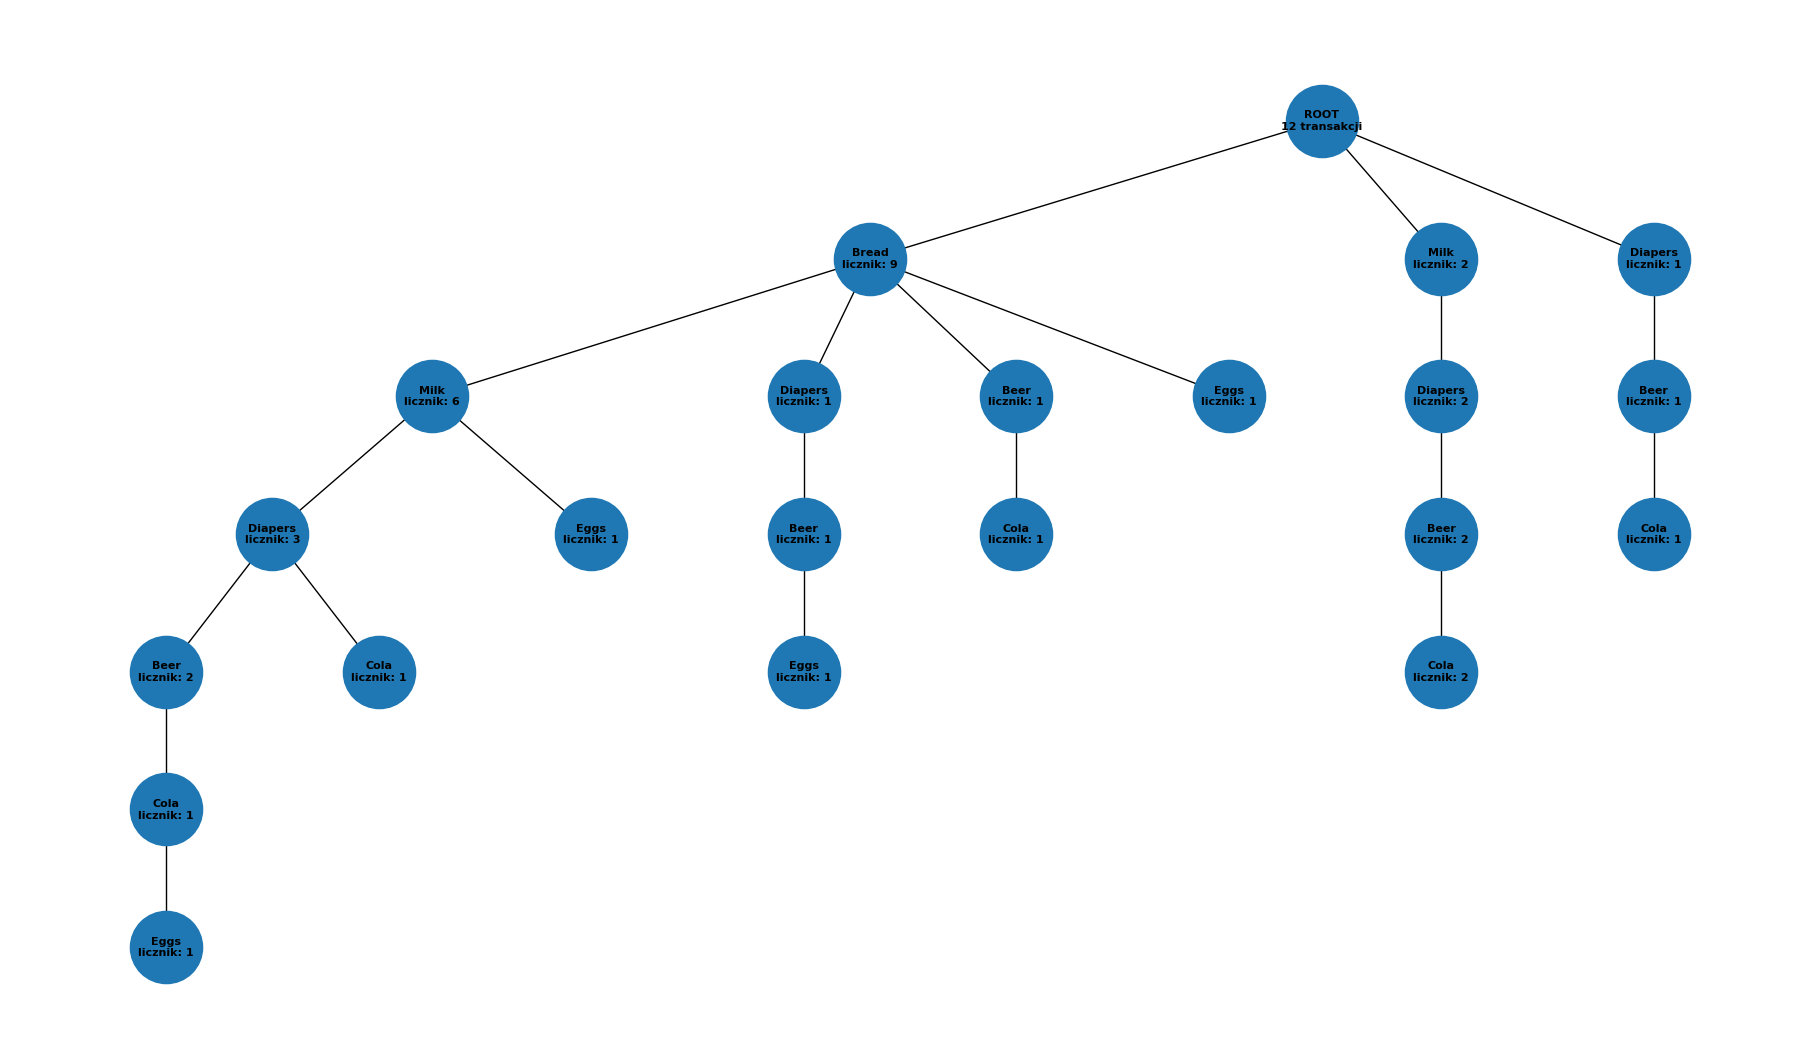

In [70]:
plt.figure(figsize=(18, 10))

nx.draw(
    graf_fp,
    pos=pozycje,
    labels=etykiety,
    with_labels=True,
    arrows=False,
    node_size=2700,
    font_size=8,
    font_weight="bold",
    linewidths=1
)

plt.title(
    "Drzewo FP-Tree dla minimalnego wsparcia 30%",
    fontsize=16
)

plt.axis("off")

#zapis wykresu do pliku
plt.savefig(
    "fp_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Wnioski

Drzewo FP-Tree zostało utworzone dla 12 transakcji przy minimalnym poziomie wsparcia wynoszącym 30%.

Wszystkie produkty występują w co najmniej 4 transakcjach, dlatego żaden produkt nie został usunięty przed budową drzewa.

Najczęstszym produktem jest Bread, który występuje w 9 transakcjach i z tego powodu główna gałąź drzewa rozpoczyna się od węzła Bread
z licznikiem równym 9.

Pozostałe gałęzie wychodzące bezpośrednio z korzenia rozpoczynają się od Milk z licznikiem 2 oraz Diapers z licznikiem 1. Oznacza to, że
odpowiednio dwie transakcje nie zawierały Bread, lecz rozpoczynały się od Milk, a jedna transakcja rozpoczynała się od Diapers.

Drzewo kompresuje wspólne prefiksy transakcji np: ścieżka Bread -> Milk występuje w 6 transakcjach, dlatego węzeł Milk pod Bread ma licznik równy 6.

## Zadanie 4 - algorytm ECLAT

Jako inny algorytm mogę zastosować ECLAT. Jest on wyraźnie inny od Apriori i FP-Growth, ponieważ korzysta z pionowej reprezentacji danych. Dla każdego produktu przechowuję numery transakcji, w których dany produkt występuje. Zbiory częste wyznaczam poprzez przecinanie zbiorów identyfikatorów transakcji.

Treść zadania nie narzuca minimalnego poziomu ufności, dlatego przyjmuję:
MinSupp = 30%, tak jak wcześniej,
MinConf = 70% jako własne, uzasadnione założenie.

W ten sposób za pomocą algorytmu ECLAT znajde zbiory częste, a następnie na ich podstawie utworzę reguły asocjacyjne.

### Przygotowanie pionowej bazy danych

In [46]:
from collections import defaultdict
from itertools import combinations
from math import ceil

import pandas as pd

MIN_SUPPORT = 0.30
MIN_CONFIDENCE = 0.70

liczba_transakcji = len(transakcje)

minimalna_liczba_wystapien = ceil(
    MIN_SUPPORT * liczba_transakcji
)

print("Liczba transakcji:", liczba_transakcji)
print("Minimalne wsparcie:", MIN_SUPPORT)
print("Minimalna liczba wystąpień:", minimalna_liczba_wystapien)
print("Minimalna ufność:", MIN_CONFIDENCE)

Liczba transakcji: 12
Minimalne wsparcie: 0.3
Minimalna liczba wystąpień: 4
Minimalna ufność: 0.7


### Tworze pionowa reprezentacje danych

In [50]:
#kluczem jest nazwa produktu, a wartością zbiór numerów transakcji
pionowa_baza = defaultdict(set)

for id_transakcji, transakcja in enumerate(transakcje, start=1):
    for produkt in transakcja:
        pionowa_baza[produkt].add(id_transakcji)

pionowa_baza_df = pd.DataFrame({
    "Produkt": sorted(pionowa_baza.keys()),
    "Identyfikatory transakcji": [
        sorted(pionowa_baza[produkt])
        for produkt in sorted(pionowa_baza.keys())
    ],
    "Liczba wystąpień": [
        len(pionowa_baza[produkt])
        for produkt in sorted(pionowa_baza.keys())
    ]
})

display(pionowa_baza_df)

,Produkt,Identyfikatory transakcji,Liczba wystąpień
0,Beer,"[2, 3, 4, 6, 10, 11, 12]",7
1,Bread,"[1, 2, 4, 5, 6, 7, 8, 9, 12]",9
2,Cola,"[3, 5, 6, 10, 11, 12]",6
3,Diapers,"[2, 3, 4, 5, 10, 11, 12]",7
4,Eggs,"[2, 7, 9, 12]",4
5,Milk,"[1, 3, 4, 5, 7, 8, 11, 12]",8


### Implementacja algorytmu ECLAT

In [54]:
def eclat(prefiks, elementy):
    wyniki = {}

    for indeks, (produkt, identyfikatory) in enumerate(elementy):
        nowy_prefiks = prefiks + (produkt,)
        liczba_wystapien = len(identyfikatory)

        if liczba_wystapien >= minimalna_liczba_wystapien:
            zbior_produktow = frozenset(nowy_prefiks)

            wyniki[zbior_produktow] = {
                "liczba_wystapien": liczba_wystapien,
                "support": liczba_wystapien / liczba_transakcji
            }

            kandydaci = []

            for kolejny_produkt, kolejne_id in elementy[indeks + 1:]:
                wspolne_id = identyfikatory.intersection(kolejne_id)

                if len(wspolne_id) >= minimalna_liczba_wystapien:
                    kandydaci.append(
                        (kolejny_produkt, wspolne_id)
                    )

            wyniki.update(
                eclat(nowy_prefiks, kandydaci)
            )

    return wyniki

#### urchomienie algorytmu

In [56]:
produkty_pionowe = sorted(
    pionowa_baza.items(),
    key=lambda element: element[0]
)

zbiory_eclat = eclat(
    prefiks=tuple(),
    elementy=produkty_pionowe
)

print(
    "Liczba zbiorów czestych znalezionych przez ECLAT:",
    len(zbiory_eclat)
)

Liczba zbiorów czestych znalezionych przez ECLAT: 19


### Wyswietlenie zbiorow częstych

In [61]:
wynik_eclat = pd.DataFrame([
    {
        "Zbiór produktów": ", ".join(sorted(zbior)),
        "Liczba elementów": len(zbior),
        "Liczba wystąpień": dane["liczba_wystapien"],
        "Wsparcie": dane["support"]
    }
    for zbior, dane in zbiory_eclat.items()
])

wynik_eclat = wynik_eclat.sort_values(
    by=[
        "Liczba elementów",
        "Wsparcie",
        "Zbiór produktów"
    ],
    ascending=[True, False, True]
).reset_index(drop=True)

wynik_eclat["Wsparcie [%]"] = (
    wynik_eclat["Wsparcie"] * 100
).round(2)

display(
    wynik_eclat[
        [
            "Zbiór produktów",
            "Liczba elementów",
            "Liczba wystąpień",
            "Wsparcie [%]"
        ]
    ]
)

,Zbiór produktów,Liczba elementów,Liczba wystąpień,Wsparcie [%]
0,Bread,1,9,75.00
1,Milk,1,8,66.67
2,Beer,1,7,58.33
3,Diapers,1,7,58.33
4,Cola,1,6,50.00
5,Eggs,1,4,33.33
6,"Beer, Diapers",2,6,50.00
7,"Bread, Milk",2,6,50.00
8,"Beer, Cola",2,5,41.67
9,"Cola, Diapers",2,5,41.67


### Generowanie reguł asocjacyjnych

In [63]:
wsparcia = {
    zbior: dane["support"]
    for zbior, dane in zbiory_eclat.items()
}

reguly = []

for zbior, wsparcie_zbioru in wsparcia.items():
    if len(zbior) < 2:
        continue

    produkty = sorted(zbior)

    #tworzenie wszystkich możliwych poprzedników
    for rozmiar in range(1, len(produkty)):
        for kombinacja in combinations(produkty, rozmiar):
            poprzednik = frozenset(kombinacja)
            nastepnik = zbior - poprzednik

            wsparcie_poprzednika = wsparcia[poprzednik]
            wsparcie_nastepnika = wsparcia[nastepnik]

            confidence = (
                wsparcie_zbioru / wsparcie_poprzednika
            )

            #sila zaleznosci pmiedzy poprzednikiem a nastepnikiem
            lift = (
                confidence / wsparcie_nastepnika
            )

            if confidence >= MIN_CONFIDENCE:
                reguly.append({
                    "Poprzednik": ", ".join(sorted(poprzednik)),
                    "Następnik": ", ".join(sorted(nastepnik)),
                    "Support": wsparcie_zbioru,
                    "Confidence": confidence,
                    "Lift": lift
                })

reguly_df = pd.DataFrame(reguly)

#### sortowanie i prezentacja wynikow:

In [67]:
reguly_df = reguly_df.sort_values(
    by=["Confidence", "Lift", "Support"],
    ascending=[False, False, False]
).reset_index(drop=True)

reguly_df["Support [%]"] = (
    reguly_df["Support"] * 100
).round(2)

reguly_df["Confidence [%]"] = (
    reguly_df["Confidence"] * 100
).round(2)

reguly_df["Lift"] = reguly_df["Lift"].round(3)

print("Liczba znalezionych reguł:", len(reguly_df))

display(
    reguly_df[
        [
            "Poprzednik",
            "Następnik",
            "Support [%]",
            "Confidence [%]",
            "Lift"
        ]
    ]
)

Liczba znalezionych reguł: 16


,Poprzednik,Następnik,Support [%],Confidence [%],Lift
0,"Beer, Milk",Diapers,33.33,100.00,1.714
1,"Cola, Milk",Diapers,33.33,100.00,1.714
2,Eggs,Bread,33.33,100.00,1.333
3,Beer,Diapers,50.00,85.71,1.469
4,Diapers,Beer,50.00,85.71,1.469
5,Cola,Beer,41.67,83.33,1.429
6,Cola,Diapers,41.67,83.33,1.429
7,"Diapers, Milk",Cola,33.33,80.00,1.600
8,"Beer, Cola",Diapers,33.33,80.00,1.371
9,"Cola, Diapers",Beer,33.33,80.00,1.371


### Wnioski

Za pomocą algorytmu ECLAT znalazłem 19 zbiorów częstych przy minimalnym poziomie wsparcia równym 30%.
Otrzymałem te same zbiory częste,które wczesniej zostały wyznaczone za pomocą algorytmów Apriori oraz FP-Growth.

Po przyjęciu minimalnego poziomu ufności wynoszącego 70% otrzymałem 16 reguł asocjacyjnych.
Największą ufność, równą 100%, uzyskały między innymi następujące reguły:

Beer, Milk -> Diapers,
Cola, Milk -> Diapers,
Eggs -> Bread

Na tej podstawie mogę stwierdzić, że we wszystkich transakcjach zawierajacych jednocześnie Beer i Milk występował również produkt Diapers.
Podobnie każda transakcja zawierająca Cola i Milk zawierała Diapers, a każda transakcja zawierająca Eggs zawierała również Bread.

Dla reguł Beer -> Diapers oraz Diapers -> Beer otrzymałem ufność równą 85,71% oraz lift wynoszący około 1,47.
Ponieważ wartość lift jest większa od 1, wskazuje to na dodatnią zależność pomiędzy tymi produktami.

## Wnioski z labolatorium:

W ramach laboratorium przeanalizowałem bazę danych zakupowych i wyznaczyłem często występujące zestawy produktów.
Algorytmy Apriori, FP-Growth oraz ECLAT dały takie same wyniki, co potwierdziło poprawność analizy.
Na podstawie zbiorów częstych utworzyłem również reguły asocjacyjne opisujące zależności między produktami, a samo laboratorium pozwoliło mi lepiej zrozumieć działanie algorytmów wyszukiwania wzorców w danych transakcyjnych.
